In [1]:
from dotenv import load_dotenv
load_dotenv()

True

### System message를 통한 더 나은 챗봇 구축
1. web검색 도구를 llm이 어쩔때 사용할지 중요하다. llm이 도구를 활용할때 어떤 부분을 유의해야할지 prompt의 system message에 넣어준다.
2. 

In [ ]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, SystemMessagePromptTemplate, HumanMessagePromptTemplate
from langchain_community.tools.tavily_search import TavilySearchResults
from datetime import datetime

# 특정 지역(비영어권)에 대해서는 할루시네이션이 자주 발생. 동적으로 오늘날짜를 알려주는것은 web_search부분에서 매우 중요.
system_prompt = f"""
You are a helpful AI Assistant that can use web search tool(tavily ai api).
You should always answer in same language as user's ask.
When use ask about the information that you can't answer, you should call the web search tool.

web search tool is useful when:
- real-time info
- local specialized info
- metric related info

you should use web search tool with the guideline below:
- Extract the user query's intent and rephrase the prompt into appropriate search query
- web search tool(Tavily AI API) can deal with sentence query. 
you don't need to limit your querying ability to generating keyword only query.
- Today is {datetime.now().strftime("%Y-%m-%d")}
"""

prompt = ChatPromptTemplate.from_messages([
    SystemMessagePromptTemplate.from_template(system_prompt),
    HumanMessagePromptTemplate.from_template("{input}") # 들어오는 값들을 input에 넣어준다.
])

llm = ChatOpenAI(
    model="gpt-4o-mini", temperature=0)

search = TavilySearchResults(max_results=3)
tools = [search]

llm_with_tools = llm.bind_tools(tools)

chain = prompt | llm_with_tools

result = chain.invoke({"input": "대한민국 축구 국가대표팀 명단 알려줘"})
print(result)
# tool_call을 사용해서 도구를 사용할 필요를 느낀다. query또한 rephrase에서 주었고, datetime을 넣어줬기 때문에 2024명단을 넣어준다.
# tavily search는 최신데이터를 기반으로 하지만, 다른 api는 다를수도 있으며, 확실하게 하기 위함이다.

content='' additional_kwargs={'tool_calls': [{'id': 'call_TqwI3XJAuepEKd4dJaw1CKpM', 'function': {'arguments': '{"query":"대한민국 축구 국가대표팀 2024 명단"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None} response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 231, 'total_tokens': 260, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_0ba0d124f1', 'finish_reason': 'tool_calls', 'logprobs': None} id='run-33f8485e-c4b8-4ca5-b82c-53480702c596-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': '대한민국 축구 국가대표팀 2024 명단'}, 'id': 'call_TqwI3XJAuepEKd4dJaw1CKpM', 'type': 'tool_call'}] usage_metadata={'input_tokens': 231, 'output_tokens': 29, 'total_tokens': 260, 'input_token_details': {'audio': 0, 'cache_read': 0}, 

In [3]:
# tool_calling값
print(result.additional_kwargs)

{'tool_calls': [{'id': 'call_TqwI3XJAuepEKd4dJaw1CKpM', 'function': {'arguments': '{"query":"대한민국 축구 국가대표팀 2024 명단"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}


In [ ]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State):
    return {"messages": [chain.invoke(state["messages"])]}

# def chatbot(state:State):
#     answer = [chain.invoke(state["messages"])]
#     return {"messages": answer}

graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools)
graph_builder.add_node("tools", tool_node)

# tools_condition에 definition을 보면, END와 tools로 가는것을 확인할 수 있다.
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("tools", "chatbot")

graph = graph_builder.compile()

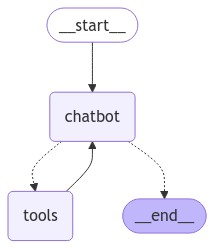

In [5]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {"messages": [("user", input("User: "))]}, config, stream_mode = "values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

대한민국 축구 국가대표팀 명단 알려줘
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (call_Cu1MwN4VYKtPBRpuYU7p4bTx)
 Call ID: call_Cu1MwN4VYKtPBRpuYU7p4bTx
  Args:
    query: 대한민국 축구 국가대표팀 명단 2024
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://sportsinsightblue.tistory.com/entry/월드컵-3차-예선-2024년-10월-한국-축구대표팀-소집명단-일정", "content": "월드컵 3차 예선 2024년 10월 한국 축구대표팀 소집명단 및 일정 월드컵 3차 예선 2024년 10월 한국 축구대표팀 소집명단 및 일정 손흥민 업적과 통산 공격포인트: 연봉, 별명, 역대 최고의 골 한국 역대 최고의 공격수, 손흥민 선수의 프로필과 연봉변화 그리고 통산 골, 어시 등 공격포인트 기록에 대하여 정리해 보고 그의 업적과 별명 마지막으로 손흥민 역대 최고의 골에 대해 알아 sportsinsightblue.tistory.com [함께 보기] - 한국 이라크 해설진 및 중계, 월드컵 3차예선 경기 일정: 홈에서 패배란 없다! 대한민국 축구대표팀이 2024년 10월 15일(화) 이라크와 2026 북중미 월드컵 3차 예선 4차전 경기를 홈에서 치른다. 이번 글에서는 손흥민, 이강인과 함께 대한민국 축구 최고 공격수로 성장한 황소 황희찬의 프로필과 역대 연봉, 통산 공격포인트

### web_search를 **Custom tool 설정을 통한 도구 통제성 향상**

In [ ]:
#!pip install tavily-python

In [50]:
from langchain_core.tools import tool
from tavily import TavilyClient

In [51]:
tavily_client = TavilyClient()
response = tavily_client.search(query="대한민국 축구 국가대표팀 명단 알려줘", topic="news", days=30)
print(response)

{'query': '대한민국 축구 국가대표팀 명단 알려줘', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.espn.com.sg/soccer/story/_/id/41812004/son-heung-min-absence-oh-hyeon-gyu-stakes-claim-south-korea-main-man-attack', 'title': "In Son's absence, Oh Hyeon-Gyu stakes claim to be South Korea's main man in attack - ESPN", 'score': 0.10070161, 'published_date': 'Tue, 15 Oct 2024 16:59:35 GMT', 'content': "In Son Heung-Min's absence, Oh Hyeon-Gyu stakes claim to be South Korea's main man in attack - ESPN In Son's absence, Oh Hyeon-Gyu stakes claim to be South Korea's main man in attack In Son Heung-Min's absence, Oh Hyeon-Gyu stakes claim to be South Korea's main man in attack Despite starting on the bench, Oh Hyeon-Gyu scored against both Jordan and Iraq in the latest round of Asian qualifiers for the 2026 FIFA World Cup to stake his claim for South Korea's sole striker berth. Oh Hyeon-Gyu's strike against Iraq -- which came just 15 minutes after he came on as a sub

In [52]:
help(tavily_client)

Help on TavilyClient in module tavily.tavily object:

class TavilyClient(builtins.object)
 |  TavilyClient(api_key: Optional[str] = None)
 |  
 |  Tavily API client class.
 |  
 |  Methods defined here:
 |  
 |  __init__(self, api_key: Optional[str] = None)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |  
 |  extract(self, urls: Union[List[str], str], **kwargs) -> dict
 |      Combined extract method.
 |  
 |  get_company_info(self, query: str, search_depth: Literal['basic', 'advanced'] = 'advanced', max_results: int = 5) -> Sequence[dict]
 |      Company information search method. Search depth is advanced by default to get the best answer.
 |  
 |  get_search_context(self, query: str, search_depth: Literal['basic', 'advanced'] = 'basic', topic: Literal['general', 'news'] = 'general', days: int = 3, max_results: int = 5, include_domains: Sequence[str] = None, exclude_domains: Sequence[str] = None, max_tokens: int = 4000, **kwargs) -> str
 |      Get the searc

In [53]:
# 랭체인을 거치지 않고 tavliy를 호출
from langchain_core.tools import tool
from tavily import TavilyClient

@tool
def search_news(keyword: str) -> str:
    """Collect recent news for the given query. """
    tavily_client = TavilyClient()
    search_results = tavily_client.search(query=keyword, topic="news", days = 30)
    return search_results

In [54]:
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

tools = [search_news]
llm_with_tools = llm.bind_tools(tools)

custom_chain = prompt|llm_with_tools

In [55]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder = StateGraph(State)

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools)
graph_builder.add_node("tools", tool_node)

# tools_condition에 definition을 보면, END와 tools로 가는것을 확인할 수 있다.
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition
)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("tools", "chatbot")

graph = graph_builder.compile()

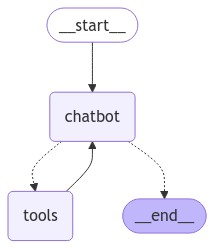

In [56]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
config = {"configurable": {"thread_id": "2"}}

events = graph.stream(
    {"messages": [("user", input("User: "))]}, config, stream_mode = "values"
)
for event in events:
    event["messages"][-1].pretty_print()

# 대한민국 축구국가 대표팀 명단 알려줘

================================ Human Message =================================

대한민국 축구국가대표팀 명단 알려줘
================================== Ai Message ==================================
Tool Calls:
  search_news (call_L1wr2MW498vDcfwqBg8gweQx)
 Call ID: call_L1wr2MW498vDcfwqBg8gweQx
  Args:
    keyword: 대한민국 축구 국가대표팀 명단 2023
================================= Tool Message =================================
Name: search_news

{"query": "대한민국 축구 국가대표팀 명단 2023", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.espn.com/soccer/story/_/id/41812004/son-heung-min-absence-oh-hyeon-gyu-stakes-claim-south-korea-main-man-attack", "title": "In Son Heung-Min's absence, Oh Hyeon-Gyu stakes claim to be South Korea's main man in attack - ESPN", "score": 0.21634248, "published_date": "Tue, 15 Oct 2024 16:45:00 GMT", "content": "In Son Heung-Min's absence, Oh Hyeon-Gyu stakes claim to be South Korea's main man in attack - ESPN In Son Heung-Min's absence, Oh Hyeon-Gy

In [59]:
# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", input("User: "))]}, config, stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

지금 상영하고 있는 영화중 인기가 가장 많은 것은?
================================== Ai Message ==================================
Tool Calls:
  search_news (call_IZEl4wGf1EvAoxDcgbpJLLlS)
 Call ID: call_IZEl4wGf1EvAoxDcgbpJLLlS
  Args:
    keyword: 현재 상영 중인 인기 영화
================================= Tool Message =================================
Name: search_news

{"query": "현재 상영 중인 인기 영화", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://deadline.com/2024/11/dont-move-beauty-in-black-ratings-netflix-top-10-1236168080/", "title": "‘Don’t Move’ Remains Netflix’s Most-Watched Weekly Title; ‘Beauty In Black’ Is No. 1 For TV - Deadline", "score": 0.7352616, "published_date": "Tue, 05 Nov 2024 20:00:00 GMT", "content": "TV TV ‘Don’t Move’ Remains Netflix’s Most-Watched Weekly Title; ‘Beauty In Black’ Is No. 1 For TV Don’t Move is still raking in a huge audience on Netflix, with 28M views from 